# Unit 6 code companion: Building and Trusting a Model

Watch a model memorize noise, watch cross-validation catch it, and watch leakage produce a 'great' model out of pure random numbers. Then see what correlated predictors do to coefficients you were about to interpret.

Run the cells in order. Each section matches a moment in the slides. The point is to see the mechanism move when you change the inputs, so change them.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression, LassoCV, lasso_path
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import make_pipeline

rng = np.random.default_rng(220)
plt.rcParams["figure.figsize"] = (7, 3.5)

## 1. Overfitting, watched happening

The truth is a gentle curve. We fit polynomials of growing degree to 25 noisy points and score them on fresh data from the same truth.

 degree   train RMSE    test RMSE
      1        0.874        1.102
      3        0.466        0.831
      5        0.435        0.906
      9        0.385       14.922
     15        0.297     4164.497


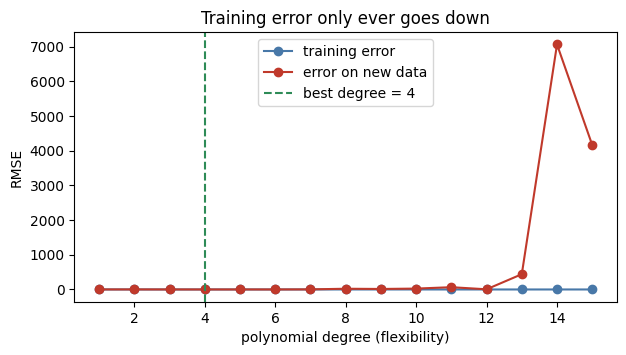

In [2]:
def truth(x):
    return 1.5*np.sin(1.2*x) + 0.4*x

n_train = 25
x_tr = np.sort(rng.uniform(-3, 3, n_train)); y_tr = truth(x_tr) + rng.normal(0, 0.5, n_train)
x_te = np.sort(rng.uniform(-3, 3, 500));     y_te = truth(x_te) + rng.normal(0, 0.5, 500)

print(f"{'degree':>7} {'train RMSE':>12} {'test RMSE':>12}")
train_e, test_e, degrees = [], [], range(1, 16)
for d in degrees:
    m = make_pipeline(PolynomialFeatures(d), LinearRegression()).fit(x_tr[:, None], y_tr)
    tr = np.sqrt(np.mean((y_tr - m.predict(x_tr[:, None]))**2))
    te = np.sqrt(np.mean((y_te - m.predict(x_te[:, None]))**2))
    train_e.append(tr); test_e.append(te)
    if d in (1, 3, 5, 9, 15):
        print(f"{d:>7} {tr:>12.3f} {te:>12.3f}")

plt.plot(list(degrees), train_e, "o-", label="training error", color="#4878a8")
plt.plot(list(degrees), test_e, "o-", label="error on new data", color="#c0392b")
plt.axvline(list(degrees)[int(np.argmin(test_e))], ls="--", color="#2e8b57",
            label=f"best degree = {list(degrees)[int(np.argmin(test_e))]}")
plt.xlabel("polynomial degree (flexibility)"); plt.ylabel("RMSE"); plt.legend()
plt.title("Training error only ever goes down"); plt.show()

The training curve slides toward zero and keeps going. Nothing in it warns you that the model got worse at its actual job around degree 6. That gap is the entire reason cross-validation exists.

## 2. Cross-validation picks the complexity for you



In [3]:
cv = KFold(5, shuffle=True, random_state=1)
print(f"{'degree':>7} {'CV RMSE':>10} {'std err':>10}")
means, ses = [], []
for d in range(1, 12):
    scores = -cross_val_score(make_pipeline(PolynomialFeatures(d), LinearRegression()),
                              x_tr[:, None], y_tr, cv=cv,
                              scoring="neg_root_mean_squared_error")
    means.append(scores.mean()); ses.append(scores.std()/np.sqrt(len(scores)))
    print(f"{d:>7} {scores.mean():>10.3f} {scores.std()/np.sqrt(len(scores)):>10.3f}")

best = int(np.argmin(means))
threshold = means[best] + ses[best]
simplest = next(i for i, m in enumerate(means) if m <= threshold)
print(f"\nlowest CV error at degree {best+1}")
print(f"one-standard-error rule picks degree {simplest+1} "
      f"(simplest model within {threshold:.3f})")

 degree    CV RMSE    std err
      1      0.923      0.057
      2      0.645      0.064
      3      0.568      0.095
      4      0.516      0.080
      5      0.484      0.076
      6      0.503      0.075
      7      1.494      0.857
      8      1.953      1.241
      9      4.690      3.465
     10      8.810      7.038
     11     30.458     26.578

lowest CV error at degree 5
one-standard-error rule picks degree 4 (simplest model within 0.559)


## 3. Leakage: how to get a great model from pure noise

This is the most important cell in the unit. The outcome is random. Nothing predicts it. We will still produce an impressive cross-validated score.

In [4]:
n, p = 80, 3000
X = rng.normal(size=(n, p))
y = rng.normal(size=n)                    # pure noise: NO signal exists

# --- THE WRONG WAY: pick the best features using all the data, then cross-validate ---
corrs = np.array([abs(np.corrcoef(X[:, j], y)[0, 1]) for j in range(p)])
top = np.argsort(-corrs)[:10]
wrong = cross_val_score(LinearRegression(), X[:, top], y, cv=cv,
                        scoring="r2").mean()

# --- THE RIGHT WAY: select inside each fold, using only that fold's training data ---
right_scores = []
for tr_idx, te_idx in cv.split(X):
    c = np.array([abs(np.corrcoef(X[tr_idx, j], y[tr_idx])[0, 1]) for j in range(p)])
    sel = np.argsort(-c)[:10]
    m = LinearRegression().fit(X[tr_idx][:, sel], y[tr_idx])
    ss_res = ((y[te_idx] - m.predict(X[te_idx][:, sel]))**2).sum()
    ss_tot = ((y[te_idx] - y[tr_idx].mean())**2).sum()
    right_scores.append(1 - ss_res/ss_tot)

print(f"select first, then cross-validate  : R^2 = {wrong:+.3f}   <-- looks like a real model")
print(f"select inside each fold (correct)  : R^2 = {np.mean(right_scores):+.3f}   <-- the truth")
print("\nThere is no signal in this data at all. The first number is manufactured entirely")
print("by letting the feature selection peek at the outcomes it would later be graded on.")

select first, then cross-validate  : R^2 = +0.339   <-- looks like a real model
select inside each fold (correct)  : R^2 = -0.424   <-- the truth

There is no signal in this data at all. The first number is manufactured entirely
by letting the feature selection peek at the outcomes it would later be graded on.


## 4. Multicollinearity: coefficients that cannot be trusted individually



In [5]:
cars = pd.read_csv("https://richardson.byu.edu/220/cars.csv").dropna()
print(f"corr(weight, displacement) = {cars.weight.corr(cars.displacement):.3f}\n")

coefs = []
for _ in range(500):
    samp = cars.sample(len(cars), replace=True)
    fit = sm.OLS(samp.mpg, sm.add_constant(samp[["weight", "displacement"]])).fit()
    coefs.append([fit.params["weight"], fit.params["displacement"]])
coefs = np.array(coefs)

full = sm.OLS(cars.mpg, sm.add_constant(cars[["weight", "displacement"]])).fit()
print(f"weight coefficient      : {full.params['weight']:+.5f}  "
      f"(bootstrap range {np.percentile(coefs[:,0],2.5):+.5f} to {np.percentile(coefs[:,0],97.5):+.5f})")
print(f"displacement coefficient: {full.params['displacement']:+.5f}  "
      f"(bootstrap range {np.percentile(coefs[:,1],2.5):+.5f} to {np.percentile(coefs[:,1],97.5):+.5f})")
print(f"\ncorrelation between the two ESTIMATES across resamples: "
      f"{np.corrcoef(coefs[:,0], coefs[:,1])[0,1]:+.2f}")

corr(weight, displacement) = 0.933



weight coefficient      : -0.00575  (bootstrap range -0.00725 to -0.00433)
displacement coefficient: -0.01650  (bootstrap range -0.02746 to -0.00353)

correlation between the two ESTIMATES across resamples: -0.94


The two coefficients are strongly *negatively* correlated across resamples: when the data gives more credit to weight, it takes it away from displacement. The pair is pinned down but the individuals are not. Predictions are fine. Interpreting either coefficient alone is not.

## 5. Trees, and the shape they can capture



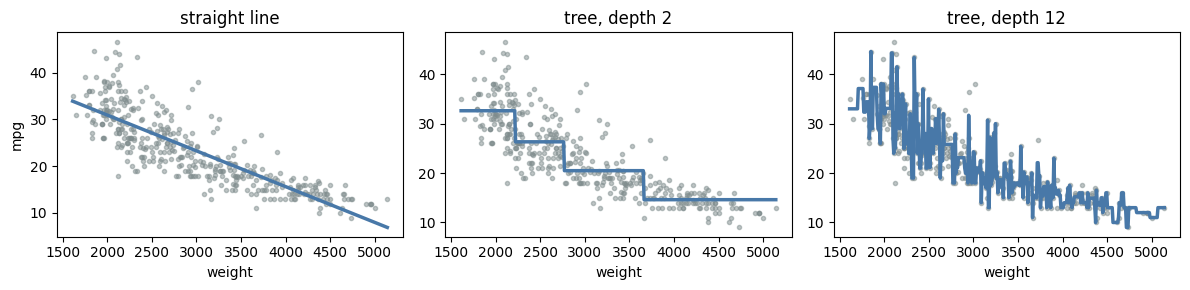

In [6]:
x = cars[["weight"]].values; y = cars["mpg"].values
grid = np.linspace(x.min(), x.max(), 400).reshape(-1, 1)

fig, axes = plt.subplots(1, 3, figsize=(12, 3))
for ax, (name, m) in zip(axes, [
        ("straight line", LinearRegression()),
        ("tree, depth 2", DecisionTreeRegressor(max_depth=2, random_state=0)),
        ("tree, depth 12", DecisionTreeRegressor(max_depth=12, random_state=0))]):
    m.fit(x, y)
    ax.plot(x, y, "o", color="#7f8c8d", ms=3, alpha=.5)
    ax.plot(grid, m.predict(grid), color="#4878a8", lw=2.5)
    ax.set_title(name); ax.set_xlabel("weight")
axes[0].set_ylabel("mpg"); plt.tight_layout(); plt.show()

## 6. Does the flexible model actually win?

Compare honestly, on the same folds, and look at the fold-to-fold noise before declaring a winner.

In [7]:
feats = ["weight", "horsepower", "displacement", "acceleration", "model_year", "cylinder"]
Xc, yc = cars[feats].values, cars["mpg"].values

for name, model in [("linear regression", LinearRegression()),
                    ("tree (depth 4)", DecisionTreeRegressor(max_depth=4, random_state=0)),
                    ("random forest", RandomForestRegressor(n_estimators=300, random_state=0))]:
    sc = -cross_val_score(model, Xc, yc, cv=cv, scoring="neg_root_mean_squared_error")
    print(f"{name:>20}: RMSE {sc.mean():.3f}  (fold-to-fold SD {sc.std():.3f})")

   linear regression: RMSE 3.485  (fold-to-fold SD 0.282)
      tree (depth 4): RMSE 3.388  (fold-to-fold SD 0.550)


       random forest: RMSE 2.740  (fold-to-fold SD 0.383)


Read the second column before celebrating the first. If two models differ by less than the fold-to-fold spread, you have not shown that one is better. You have shown they are hard to tell apart on this much data.